# GLU vs. GRSU vs. ALMM

In [1]:
# Import necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import graphlearning as gl
from scipy.special import jn
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter
from itertools import product
from joblib import Parallel, delayed
from scipy.optimize import nnls
from sklearn.decomposition import PCA

# Import functions from Chen et. al.
from graph_active_learning_functions import *

## Synthetic Linear Data

In [2]:
# Generate Random data
samples = 2000 # N
channels = 300 # p
np.random.seed(42)

# Create random labels and abundance matrix
L = np.random.uniform(0,1,samples)
A = np.array([L,1-L])

# Smooth out the two spectras
s_1 = gaussian_filter(np.random.uniform(0,1,channels),2)
s_2 = gaussian_filter(np.random.uniform(0,1,channels),2)

S_T = np.array([s_1,s_2])

S = S_T.T


# Create the linear mixing model
X=S@A
error_std = 0.05

E = np.random.normal(loc=0.0, scale=error_std, size=X.shape)

X=X+E

In [3]:
# GLU

# Pick best parameters
#alpha_vals = np.array([10, 20, 50, 100])
#lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
#gamma_vals = 10.0 ** np.arange(-2, 3)
#rho_vals = 10.0 ** np.arange(-2, 3)

#best_params_GLU = parameter_testing(X, A, S, samples, 
                                #alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
                                #print_bool = False, GRSU_bool = False)

alpha_0 = 10
lam_0 = 1
gamma_0 = 0.01
rho_0 = 0.01

# Best RMSE + SAD: 23.875179751944458
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

# Run algorithm on chosen parameters
A_f_GLU, S_f_GLU, A_rmse_GLU, S_sad_GLU = run_unmixing_pipeline_example(X, A, S, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = False)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 2000)
Final End-member Matrix Shape: (300, 2)
Final Abundance RMSE: 21.39481515797743
Final Endmember SAD: 2.4803645939670274


In [4]:
# GRSU

# Pick best parameters
#best_params_GRSU = parameter_testing(X, A, S, samples, 
                                #alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
                                #print_bool = False, GRSU_bool = True)

alpha_0 = 10
lam_0 = 10
gamma_0 = 0.01
rho_0 = 0.01

# Best RMSE + SAD: 5.170721801379891
# Best alpha: 10
# Best lambda: 10
# Best gamma: 0.01
# Best rho: 0.01

# Run on best parameters
A_f_GRSU, S_f_GRSU, A_rmse_GRSU, S_sad_GRSU = run_unmixing_pipeline_example(X, A, S, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 2000)
Final End-member Matrix Shape: (300, 2)
Final Abundance RMSE: 3.073787352255858
Final Endmember SAD: 2.0969344491240327


In [5]:
# ALMM

alpha = 2e-4
beta = 2e-3
gamma = 5e-3
eta = 5e-3
maxIter = 50 # changed from 30

# Pick the best alpha
# best_rmse = np.inf
# best_alpha = None

# alpha_vals = [2e-3, 6e-4, 2e-4, 6e-5, 2e-5]

# for a in alpha_vals:

#     E_f, A_f, T_f, B_f = algo_2_almm(X, S, a, beta, gamma, eta, maxIter)

#     rmse = RMSE(A_f, A)  # Calculate RMSE
#     print(f"alpha={a:.6f} -> RMSE={rmse:.4f}")

#     if rmse < best_rmse:
#         best_rmse = rmse
#         best_alpha = a

# print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}")

# alpha=0.002000 -> RMSE=19.5170
# alpha=0.000600 -> RMSE=11.6159
# alpha=0.000200 -> RMSE=9.9700
# alpha=0.000060 -> RMSE=12.6079
# alpha=0.000020 -> RMSE=13.9909

# Best alpha: 0.0002, RMSE: 9.9700

E_f_ALMM, A_f_ALMM, T_f_ALMM, B_f_ALMM = algo_2_almm(X, S, alpha, beta, gamma, eta, maxIter)

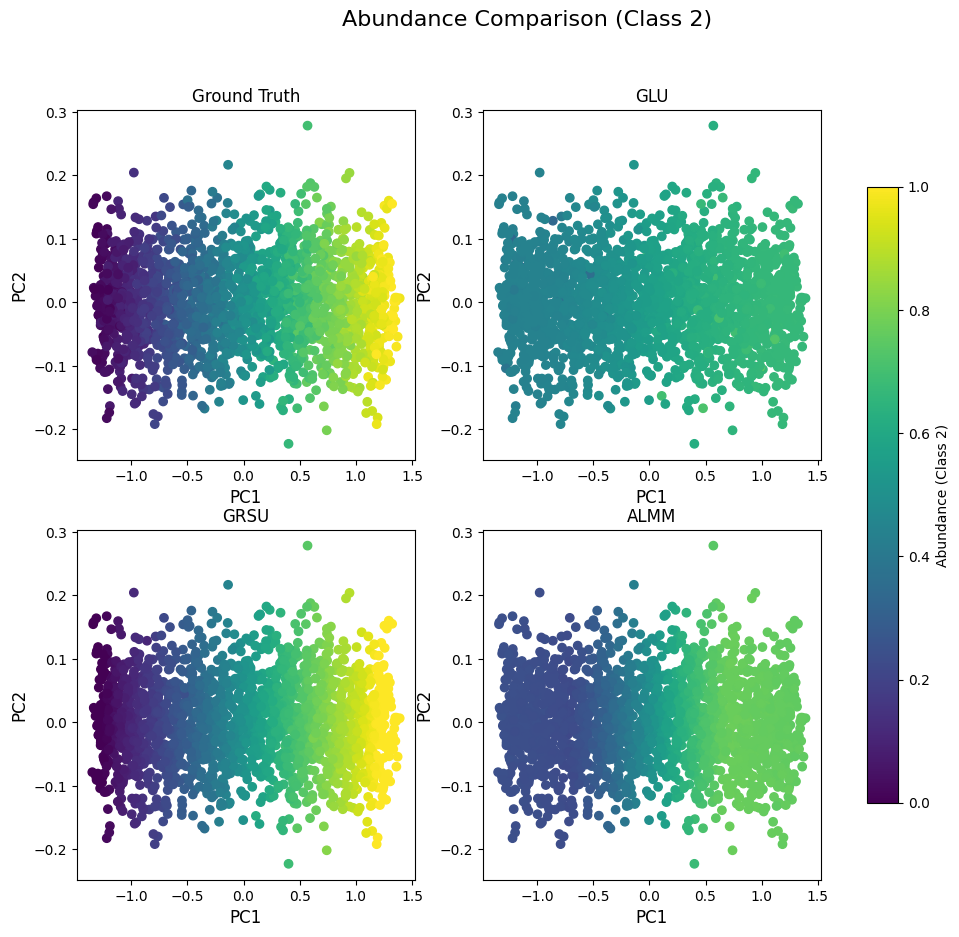

In [6]:
## Plotting abundance maps

# Run PCA
pca1 = PCA(n_components=2)
X_pca1 = pca1.fit_transform(X.T)

# Visualizing
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#endmember_idx = 0  # which endmember/class you're visualizing

vmin, vmax = 0, 1  # fixed scale so colors are directly comparable across all 4 plots

# Top-left: Ground truth
sc1 = axes[0, 0].scatter(X_pca1[:,0], X_pca1[:,1], c=A[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0, 0].set_title('Ground Truth')

# Top-right: GLU
sc2 = axes[0,1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_GLU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0,1].set_title('GLU')

# Bottom-left: GRSU
sc3 = axes[1,0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_GRSU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1,0].set_title('GRSU')

# Bottom-right: ALMM
sc4 = axes[1, 1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_ALMM[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1, 1].set_title('ALMM')

for ax in axes.flat:
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)

fig.suptitle(f'Abundance Comparison (Class 2)', fontsize=16)

fig.colorbar(sc4, ax=axes, label=f'Abundance (Class 2)', shrink=0.8)

plt.show()

## Nonlinear Synthetic Data

In [7]:
data = np.load('my_custom_dataset.npy', allow_pickle=True).item()

# 1. See what keys are inside
# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 2. Inspect the exact shapes of the arrays
print("Shape of X (HSI Image):", data['X'].shape)
print("Shape of A_gt (Abundance Map):", data['A_gt'].shape)
print("Shape of S_gt (Endmember Spectra):", data['S_gt'].shape)

# 3. (Optional) Look at a small slice of the actual numbers
print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (HSI Image): (10, 250, 30)
Shape of A_gt (Abundance Map): (2, 2500)
Shape of S_gt (Endmember Spectra): (30, 2)

First pixel's spectra in X:
 [0.53910909 0.46784716 0.51651596 0.51511246 0.54243879 0.52064358
 0.51943605 0.52593777 0.53434579 0.51118315 0.51952582 0.45491021
 0.48604329 0.50390983 0.47451358 0.48900189 0.55472187 0.53542633
 0.46566486 0.46165341 0.51478674 0.51466119 0.51180038 0.5016153
 0.53460008 0.47453781 0.47549698 0.51345648 0.47629452 0.53555711]


In [8]:
# Grabbing X, S, and A from the file
A_gt_nl = data['A_gt']
S_gt_nl = data['S_gt']
X_nl = data['X']

# Checking the shapes
print(type(S_gt_nl))
print(S_gt_nl.shape)
print(S_gt_nl.dtype)

print(type(A_gt_nl))
print(A_gt_nl.shape)
print(A_gt_nl.dtype)

print("Shape of X:", X_nl.shape)

# Reshaping X from spatial image (10, 1000, 30) to 2D image (30, 10000)
H, W, p = X_nl.shape  # H=10, W=1000, p=30
X_nl_flat = X_nl.reshape(-1, p).T  # reshape to (p, N) = (30, 10000)

print(X_nl_flat.shape)  # should print (30, 10000)

<class 'numpy.ndarray'>
(30, 2)
float64
<class 'numpy.ndarray'>
(2, 2500)
float64
Shape of X: (10, 250, 30)
(30, 2500)


In [18]:
# GLU

# Pick best parameters
# samples = 2500
# alpha_vals = np.array([10, 20, 50, 100])
# lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
# gamma_vals = 10.0 ** np.arange(-2, 3)
# rho_vals = 10.0 ** np.arange(-2, 3)

# best_params_GLU = parameter_testing(X_nl_flat, A_gt_nl, S_gt_nl, samples, 
#                                 alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
#                                 print_bool = False, GRSU_bool = False)

samples = 2500
alpha_0 = 100
lam_0 = 1
gamma_0 = 0.01
rho_0 = 0.01

# Best RMSE + SAD: 88.91835930807841
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

# Run algorithm on chosen parameters
A_f_nl_GLU, S_f_nl_GLU, A_rmse_nl_GLU, S_sad_nl_GLU = run_unmixing_pipeline_example(X_nl_flat, A_gt_nl, S_gt_nl, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = False)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 2500)
Final End-member Matrix Shape: (30, 2)
Final Abundance RMSE: 27.072536191060763
Final Endmember SAD: 61.84582311701765


In [19]:
# GRSU

# Pick best parameters
# best_params_GRSU = parameter_testing(X_nl_flat, A_gt_nl, S_gt_nl, samples, 
#                                 alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 2,
#                                 print_bool = False, GRSU_bool = True)

alpha_0 = 100
lam_0 = 1
gamma_0 = 0.01
rho_0 = 10

# Best RMSE + SAD: 78.11969096116576
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 10.0

# Run on best parameters
A_f_nl_GRSU, S_f_nl_GRSU, A_rmse_nl_GRSU, S_sad_nl_GRSU = run_unmixing_pipeline_example(X_nl_flat, A_gt_nl, S_gt_nl, samples, 
                                                        alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 2,
                                                        print_bool = True, GRSU_bool = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing...
Pipeline Complete!

Final Abundance Map Shape: (2, 2500)
Final End-member Matrix Shape: (30, 2)
Final Abundance RMSE: 16.16918732326605
Final Endmember SAD: 61.9505036378997


In [ ]:
# ALMM

alpha = 2e-3
beta = (1e-3 + 1e-2)/2
gamma = (1e-3 + 1e-2)/2
eta = (1e-3 + 1e-2)/2
maxIter = 50 # changed from 30

# Pick the best alpha
best_rmse = np.inf
best_alpha = None

alpha_vals = [2e-3, 6e-4, 2e-4, 6e-5, 2e-5]

for a in alpha_vals:

    E_f, A_f, T_f, B_f = algo_2_almm(X_nl_flat, S_gt_nl, a, beta, gamma, eta, maxIter)

    rmse = RMSE(A_f, A_gt_nl)  # Calculate RMSE
    print(f"alpha={a:.6f} -> RMSE={rmse:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = a

print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}")


E_f_nl_ALMM, A_f_nl_ALMM, T_f_nl_ALMM, B_f_nl_ALMM = algo_2_almm(X_nl_flat, S_gt_nl, best_alpha, beta, gamma, eta, maxIter)

alpha=0.002000 -> RMSE=73.8551
alpha=0.000600 -> RMSE=71.0646
alpha=0.000200 -> RMSE=67.2571
alpha=0.000060 -> RMSE=61.1394
alpha=0.000020 -> RMSE=58.8132

Best alpha: 2e-05, RMSE: 58.8132


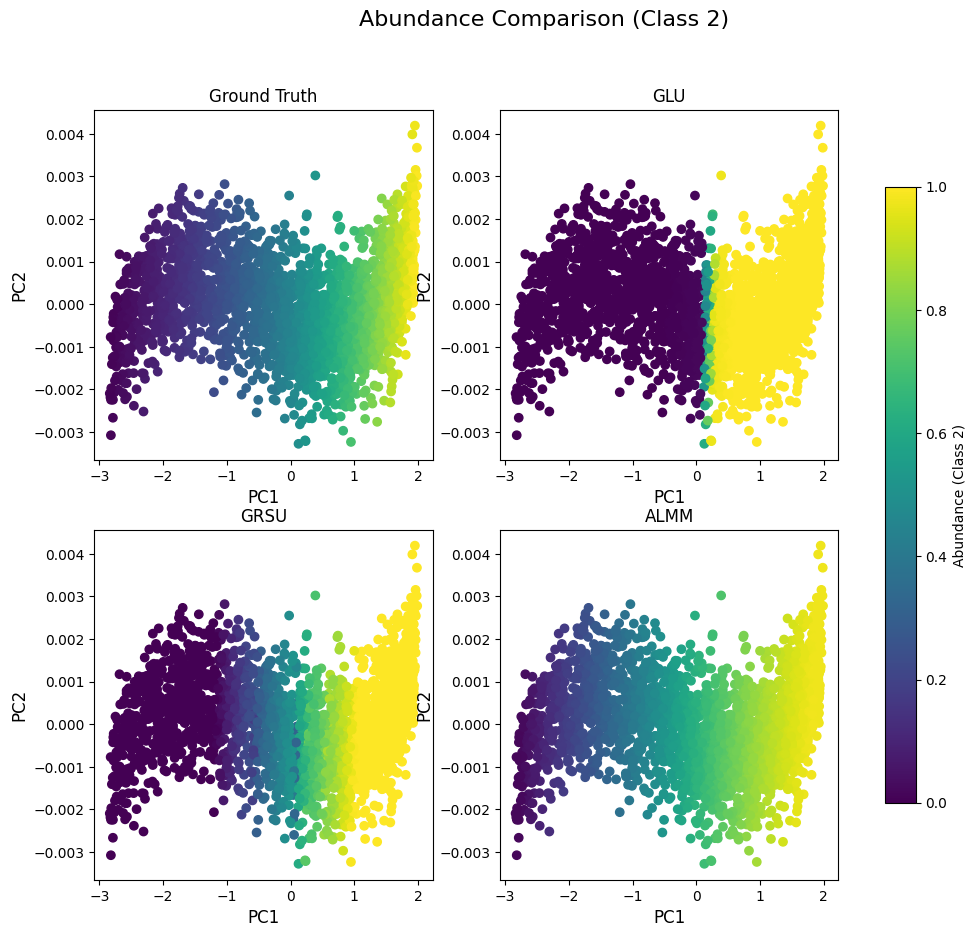

In [31]:
## Plotting abundance maps

# Run PCA
pca1 = PCA(n_components=2)
X_pca1 = pca1.fit_transform(X_nl_flat.T)

# Visualizing
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#endmember_idx = 0  # which endmember/class you're visualizing

vmin, vmax = 0, 1  # fixed scale so colors are directly comparable across all 4 plots

# Top-left: Ground truth
sc1 = axes[0, 0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_gt_nl[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0, 0].set_title('Ground Truth')

# Top-right: GLU
sc2 = axes[0,1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_nl_GLU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[0,1].set_title('GLU')

# Bottom-left: GRSU
sc3 = axes[1,0].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_nl_GRSU[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1,0].set_title('GRSU')

# Bottom-right: ALMM
# print(np.corrcoef(A_f_nl_ALMM[0], A_gt_nl[0])[0,1])
# Negative correlation, so flip the abundances and recalculate RMSE
A_f_nl_ALMM_fixed = 1 - A_f_nl_ALMM

# print(RMSE(A_f_nl_ALMM_fixed, A_gt_nl))
# RMSE: 14.052370817831669

sc4 = axes[1, 1].scatter(X_pca1[:,0], X_pca1[:,1], c=A_f_nl_ALMM_fixed[0], vmin=vmin, vmax=vmax, cmap='viridis')
axes[1, 1].set_title('ALMM')

for ax in axes.flat:
    ax.set_xlabel('PC1', fontsize=12)
    ax.set_ylabel('PC2', fontsize=12)

fig.suptitle(f'Abundance Comparison (Class 2)', fontsize=16)

fig.colorbar(sc4, ax=axes, label=f'Abundance (Class 2)', shrink=0.8)

plt.show()

## Chemical Synthetic Data


In [ ]:
# TODO: figure out the code from old_chem_code

# Urban Dataset

In [42]:
# Load the file. We use allow_pickle=True because it contains a Python dictionary.
# The .item() extracts the dictionary from the 0-D numpy array it gets wrapped in.
data = np.load('processed_data/processed_data/urban/urban_processed_data.npy', allow_pickle=True).item()

# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 1. Let's check X just to be sure it IS an array
print("Type of X:", type(data['X']))
if hasattr(data['X'], 'shape'):
    print("Shape of X:", data['X'].shape)

# 2. Let's peek inside the dictionary 'A'
print("\nType of A:", type(data['A']))
if isinstance(data['A'], dict):
    print("Keys inside A:", data['A'].keys())

# 3. Let's peek inside the dictionary 'S'
print("\nType of S:", type(data['S']))
if isinstance(data['S'], dict):
    print("Keys inside S:", data['S'].keys())

# 3. (Optional) Look at a small slice of the actual numbers
#print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['A', 'S', 'err_all', 'X', 'dataset', 'shape', 't_MSC', 't_EGU'])
Type of X: <class 'numpy.ndarray'>
Shape of X: (162, 94249)

Type of A: <class 'dict'>
Keys inside A: dict_keys(['A_ref', 'A_fclsu', 'A_MBO', 'A_graphL', 'A_MSC', 'A_qmv', 'A_nmf', 'A_EGU'])

Type of S: <class 'dict'>
Keys inside S: dict_keys(['S_ref', 'S_fclsu', 'S_MBO', 'S_graphL', 'S_MSC', 'S_qmv', 'S_nmf', 'S_EGU'])


In [43]:
A_list= data['A']
S_list = data['S']
X_urban = data['X']


S_gt_urban = S_list['S_ref']
A_gt_urban = A_list['A_ref']


print(S_gt_urban.shape)
print(A_gt_urban.shape)

(162, 4)
(4, 94249)


In [44]:
# Example: grab a 50x50 spatial patch instead of random pixels
H, W = 307, 307
patch_size = 50
row_start, col_start = 100, 100  # pick wherever

X_urban_img = X_urban.T.reshape(H, W, -1)  # reshape to (307, 307, p)
patch = X_urban_img[row_start:row_start+patch_size, col_start:col_start+patch_size, :]
X_urban_test = patch.reshape(-1, patch.shape[-1]).T  # back to (p, N_patch)

A_gt_urban_img = A_gt_urban.T.reshape(H, W, -1)
patch_gt_urban = A_gt_urban_img[row_start:row_start+patch_size, col_start:col_start+patch_size, :]
A_gt_urban_test = patch_gt_urban.reshape(-1, patch_gt_urban.shape[-1]).T

In [ ]:
# GLU

# Pick best parameters
samples = 2500
alpha_vals = np.array([10, 20, 50, 100])
lam_vals = np.sort(np.concatenate([10**np.arange(4), 5 * 10**np.arange(4)]))
gamma_vals = 10.0 ** np.arange(-2, 3)
rho_vals = 10.0 ** np.arange(-2, 3)

best_params_GLU = parameter_testing(X_urban_test, A_gt_urban_test, S_gt_urban, samples, 
                                alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 4,
                                print_bool = False, GRSU_bool = False)

samples = 2500
alpha_0 = 100
lam_0 = 1
gamma_0 = 0.01
rho_0 = 0.01

# Best RMSE + SAD: 30.041309840322626
# Best alpha: 50
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01

# Run algorithm on chosen parameters
# A_f_nl_GLU, S_f_nl_GLU, A_rmse_nl_GLU, S_sad_nl_GLU = run_unmixing_pipeline_example(X_nl_flat, A_gt_nl, S_gt_nl, samples, 
#                                                         alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 4,
#                                                         print_bool = True, GRSU_bool = False)

Best RMSE + SAD: 30.041309840322626
Best alpha: 50
Best lambda: 1
Best gamma: 0.01
Best rho: 0.01


In [ ]:
# GRSU

# Pick best parameters
best_params_GRSU = parameter_testing(X_urban_test, A_gt_urban_test, S_gt_urban, samples, 
                                alpha_vals, lam_vals, gamma_vals, rho_vals, m_0 = 4,
                                print_bool = False, GRSU_bool = True)

alpha_0 = 100
lam_0 = 1
gamma_0 = 0.01
rho_0 = 10

# Best RMSE + SAD: 27.562386077293002
# Best alpha: 20
# Best lambda: 100
# Best gamma: 1.0
# Best rho: 0.1

# Run on best parameters
# A_f_nl_GRSU, S_f_nl_GRSU, A_rmse_nl_GRSU, S_sad_nl_GRSU = run_unmixing_pipeline_example(X_urban_test, A_gt_urban_test, S_gt_urban, samples, 
#                                                         alpha = alpha_0, lam = lam_0, gamma = gamma_0, rho = rho_0, m_0 = 4,
#                                                         print_bool = True, GRSU_bool = True)

Best RMSE + SAD: 27.562386077293002
Best alpha: 20
Best lambda: 100
Best gamma: 1.0
Best rho: 0.1


In [ ]:
# ALMM
# TODO Run this

# Parameters picked directly from paper
alpha = 5e-2
beta = 5e-2
gamma = 1e-2
eta = 1e-2
maxIter = 50 # changed from 30

# Pick the best alpha
best_rmse = np.inf
best_alpha = None

alpha_vals = [alpha, alpha/10, alpha/100, alpha/1000, alpha/10000]

for a in alpha_vals:

    E_f, A_f, T_f, B_f = algo_2_almm(X_urban_test, S_gt_urban, a, beta, gamma, eta, maxIter)

    rmse = RMSE(A_f, A_gt_urban_test)  # Calculate RMSE
    print(f"alpha={a:.6f} -> RMSE={rmse:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = a

print(f"\nBest alpha: {best_alpha}, RMSE: {best_rmse:.4f}")


E_f_urban_ALMM, A_f_urban_ALMM, T_f_urban_ALMM, B_f_urban_ALMM = algo_2_almm(X_urban_test, S_gt_urban, best_alpha, beta, gamma, eta, maxIter)